## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [ ]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [ ]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [3]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


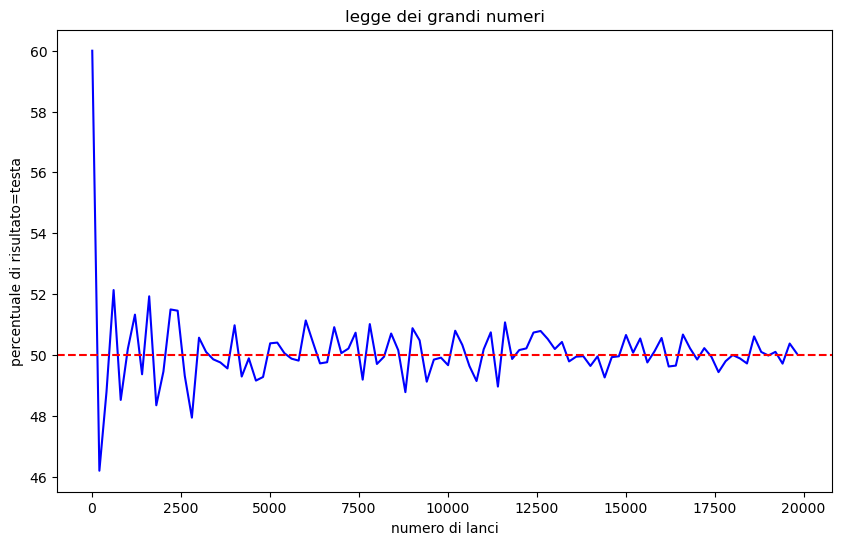

In [4]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [ ]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Caricamento del dataset Titanic
df = sns.load_dataset("titanic")

# --- Dimensioni del dataset ---
righe, colonne = df.shape
print(f"Il dataset ha {righe} righe e {colonne} colonne.\n")

# --- Controllo valori mancanti per colonna ---
print("Valori mancanti per colonna:")
print(df.isnull().sum())
print("-" * 40)

# --- Riempimento 'Embarked' con il valore più frequente (moda) ---
moda_embarked = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(moda_embarked)
# Se presente, sistemiamo anche la colonna 'embark_town' (corrispettiva nel dataset di seaborn)
if "embark_town" in df.columns:
    df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# --- Controllo righe duplicate ---
duplicati = df.duplicated().sum()
print(f"Numero di righe duplicate nel dataset: {duplicati}\n")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
      species  petal_length  petal_width
0      setosa         1.462        0.246
1  versicolor         4.260        1.326
2   virginica         5.552        2.026


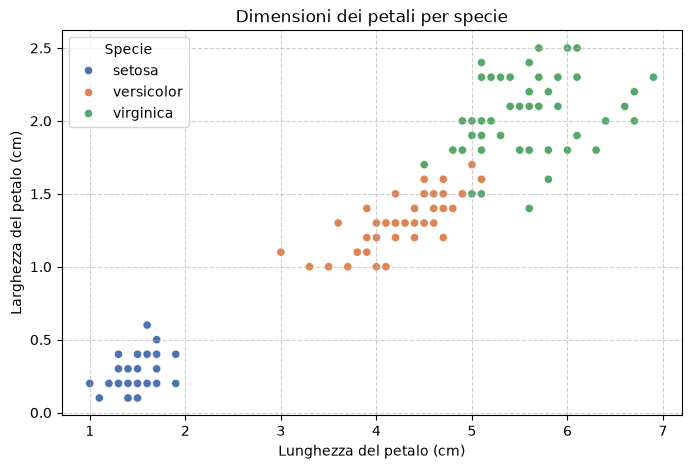

      species  Area_Minima  Area_Media  Area_Massima  Dev_Standard
0      setosa         0.11      0.3656          0.96      0.181155
1  versicolor         3.30      5.7204          8.64      1.368403
2   virginica         7.50     11.2962         15.87      2.157412


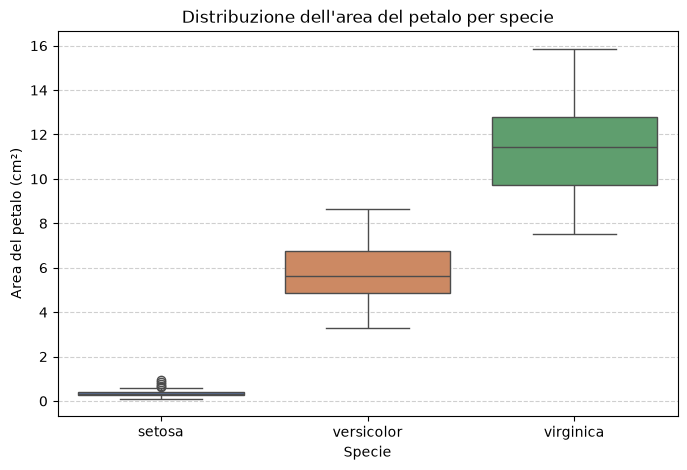

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()




# Conteggio dei campioni per specie
print(df["species"].value_counts())

# Calcolo delle medie per specie
medie_petali = (
    df.groupby("species")[["petal_length", "petal_width"]].mean().reset_index()
)
print(medie_petali)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="petal_length", y="petal_width", hue="species", palette="deep"
)

plt.title("Dimensioni dei petali per specie")
plt.xlabel("Lunghezza del petalo (cm)")
plt.ylabel("Larghezza del petalo (cm)")
plt.legend(title="Specie")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Creazione della colonna area
df["petal_area"] =df["petal_length"] * df["petal_width"]

# Analisi statistica dell'area per specie
analisi_area = (
    df.groupby("species")["petal_area"]
    .agg(
        Area_Minima="min",
        Area_Media="mean",
        Area_Massima="max",
        Dev_Standard="std",
    )
    .reset_index()
)

print(analisi_area)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="petal_area", hue="species", palette="deep")

plt.title("Distribuzione dell'area del petalo per specie")
plt.xlabel("Specie")
plt.ylabel("Area del petalo (cm²)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()